<a href="https://colab.research.google.com/github/Knchna/ICT_AI-ML/blob/main/Jul_13_Intermediate_Assessment_2_Supervised_Learning_on_Heart_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# mutual information
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import mutual_info_regression

# scaling and encoding
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.model_selection import train_test_split

# classification
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# regression
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Load Dataset

In [2]:
filepath = "/content/drive/MyDrive/ICT_AIML Class/Datasets/heart_disease.csv"

In [3]:
df_heart = pd.read_csv(filepath)
df_heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df_heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [5]:
# Inference:
  # No missing values are there
  # all values are encoded as numerical, including conceptually categorical ones

In [6]:
df_heart.shape

(1025, 14)

In [7]:
df_heart.columns.tolist()

['age',
 'sex',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal',
 'target']

In [10]:
# printing descriptive statistics summary

df_heart.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


# Data Understanding

In [ ]:
# Dataset Details:
  # This is originally a Heart Disease Binary Classification Dataset as 'target' is defined as such
  # Contains 14 numerical features by datatype
  # Contain 1,025 instances

In [ ]:
# Column Details:
'''
1. 'age'                                      : Age of the individual
2. 'sex'                                      : Gender of the individual          (0 = female, 1 = male)
3. chest pain type              ['cp']        : Type of chest pain                (4 categories: 0-3)
4. resting blood pressure       ['trestbps']  : Resting blood pressure (in mm Hg)
5. serum cholesterol            ['chol']      : Cholesterol level (in mg/dl)                                  [Target for regression]
6. fasting blood sugar          ['fbs']       : Fasting blood sugar > 120 mg/dl   (1 = true, 0 = false)
7. resting electrocardiographic ['restecg']   : ECG results
                      results                  (0 = normal, 1 = ST-T abnormality, 2 = probable/definite left ventricular hypertrophy)
8. maximum heart rate achieved  ['thalach']   : cont. num values
9. exercise induced angina      ['exang']     : Exercise-induced chest pain       (1 = yes, 0 = no)
10. 'oldpeak'                                 : ST depression induced by exercise relative to rest
11. 'slope'                                   : The slope of the peak exercise ST segment     (0-2)
12. number of major vessels     ['ca']        : Number of major vessels           (0-3) colored by fluoroscopy
13. 'thal'                                    : Type of thalassemia               (0 = normal, 1 = fixed defect, 2 = reversible defect)
14. 'target'                                  : Presence of heart disease         (1 = Yes, 0 = No)           [Target for classifcation]
'''

In [9]:
# No redundant columns visible from this to drop

In [11]:
# printing unique values

for i in df_heart.columns:
  print(f"Value counts in column {i} is: {df_heart[i].value_counts()} \n")
  print(f"No of unique values in column {i} is: {df_heart[i].nunique()} \n")
  print("*************************************************")

Value counts in column age is: age
58    68
57    57
54    53
59    46
52    43
56    39
51    39
62    37
60    37
44    36
64    34
41    32
63    32
61    31
67    31
55    30
65    27
42    26
43    26
53    26
45    25
66    25
46    23
48    23
50    21
47    18
49    17
35    15
70    14
39    14
38    12
68    12
71    11
40    11
69     9
34     6
37     6
29     4
76     3
77     3
74     3
Name: count, dtype: int64 

No of unique values in column age is: 41 

*************************************************
Value counts in column sex is: sex
1    713
0    312
Name: count, dtype: int64 

No of unique values in column sex is: 2 

*************************************************
Value counts in column cp is: cp
0    497
2    284
1    167
3     77
Name: count, dtype: int64 

No of unique values in column cp is: 4 

*************************************************
Value counts in column trestbps is: trestbps
120    128
130    123
140    107
110     64
150     55
138     45
128

In [15]:
# Creating copies of the same dataset df_heart, for applying classification and regression separately

df_class = df_heart.copy()    # For classification
df_reg = df_heart.copy()      # For regression

In [16]:
# For classification

num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
cat_cols = ['sex','cp','fbs','restecg','exang','slope','ca','thal']

# In cat_cols :
  # nominal cols -  'cp', 'restecg', 'thal'       -> 'cp' doesn't show severity of chest pain, instead it shows type
                                                      # => Needs OHE
  # count col -  'ca'                             -> actually a discrete numerical col, treated as cat_col due to only 4 nunique
                                                      # used as is, because it's essentially numerical column
  # ordinal cols  - 'slope'                       -> 'slope' shows slope type like up, flat and down which has ranking
                                                      # => already encoded
  # binary cols - 'sex', 'fbs', 'exang'           => Already encoded properly

target_col = 'target'   # already encoded
# Presence of heart disease (1 = Yes, 0 = No)    => Binary Classification

# Data Cleaning

## Missing Value Inspection

In [66]:
df_heart.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
# Inference:
  # No missing vlaues, as was seen in df_heart.info()

## Duplicates Handling

In [12]:
df_heart.duplicated().sum()

np.int64(723)

In [ ]:
# Inference:
  # Approx 70% of the rows are duplicate -> unusually high
  # Could be error of the dataset

In [13]:
# To use the dataframe w/o removing duplicate rows
df_heart_nodup = df_heart.drop_duplicates()

In [14]:
# After removing duplicate rows
df_heart_nodup.shape

(302, 14)

## Outlier Handling

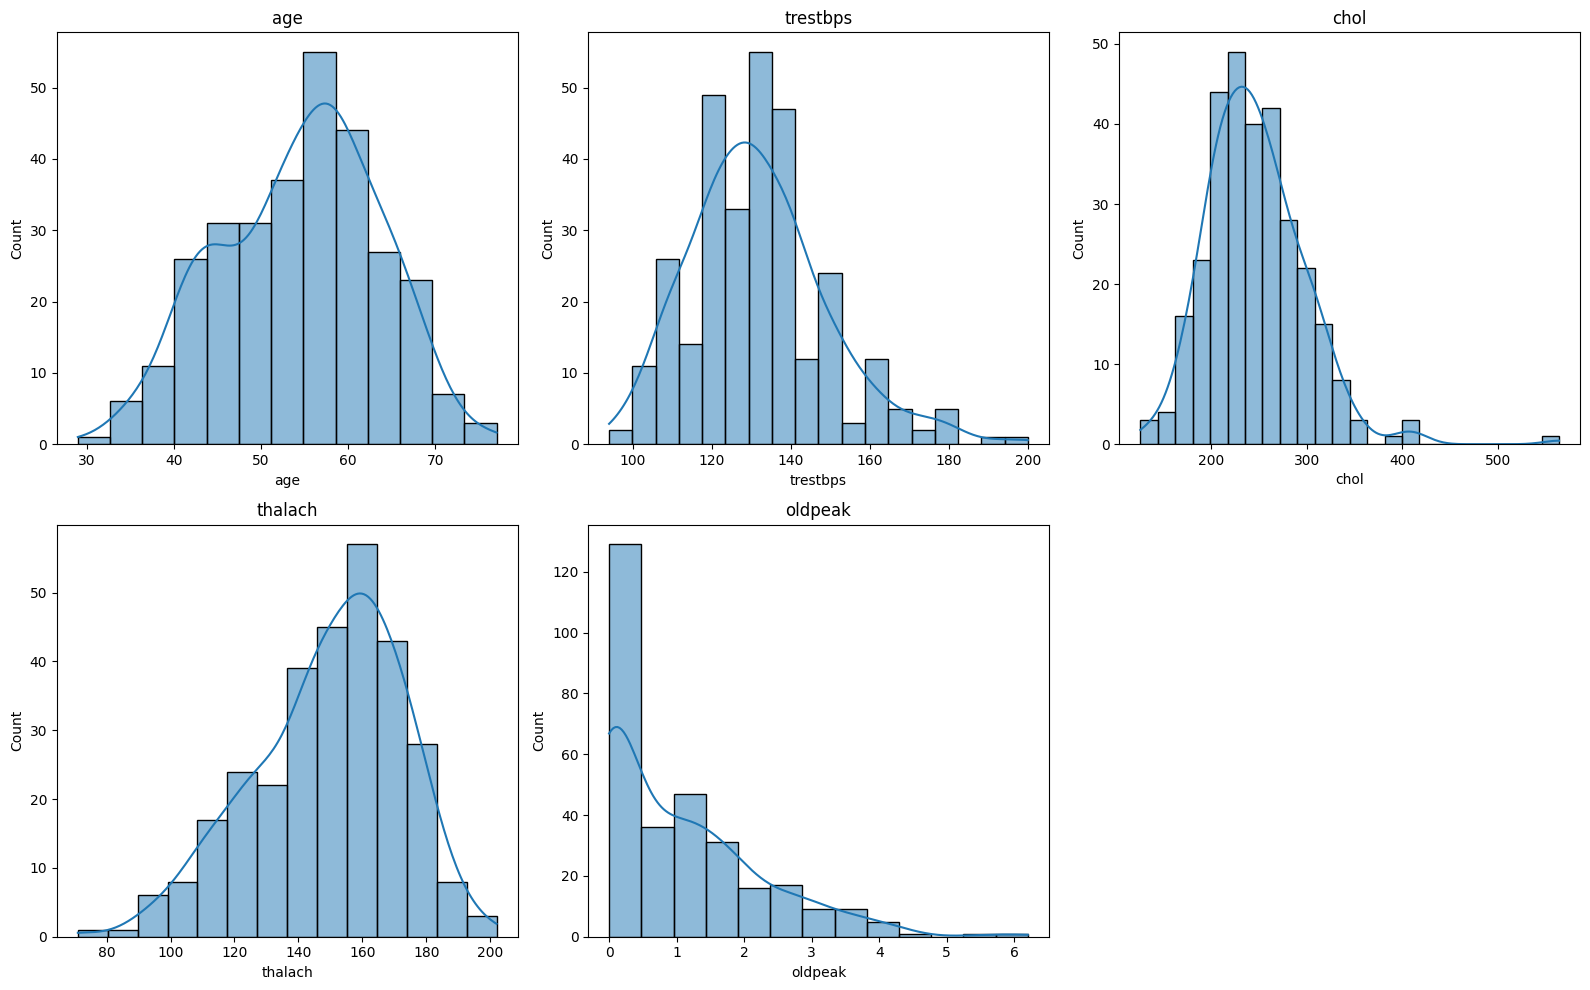

In [17]:
plt.figure(figsize = (16, 10))
i = 1
for column in num_cols:
  plt.subplot(2, 3, i)
  sns.histplot(df_class[column], kde=True)
  plt.title(column)
  i += 1
plt.tight_layout()
plt.show()

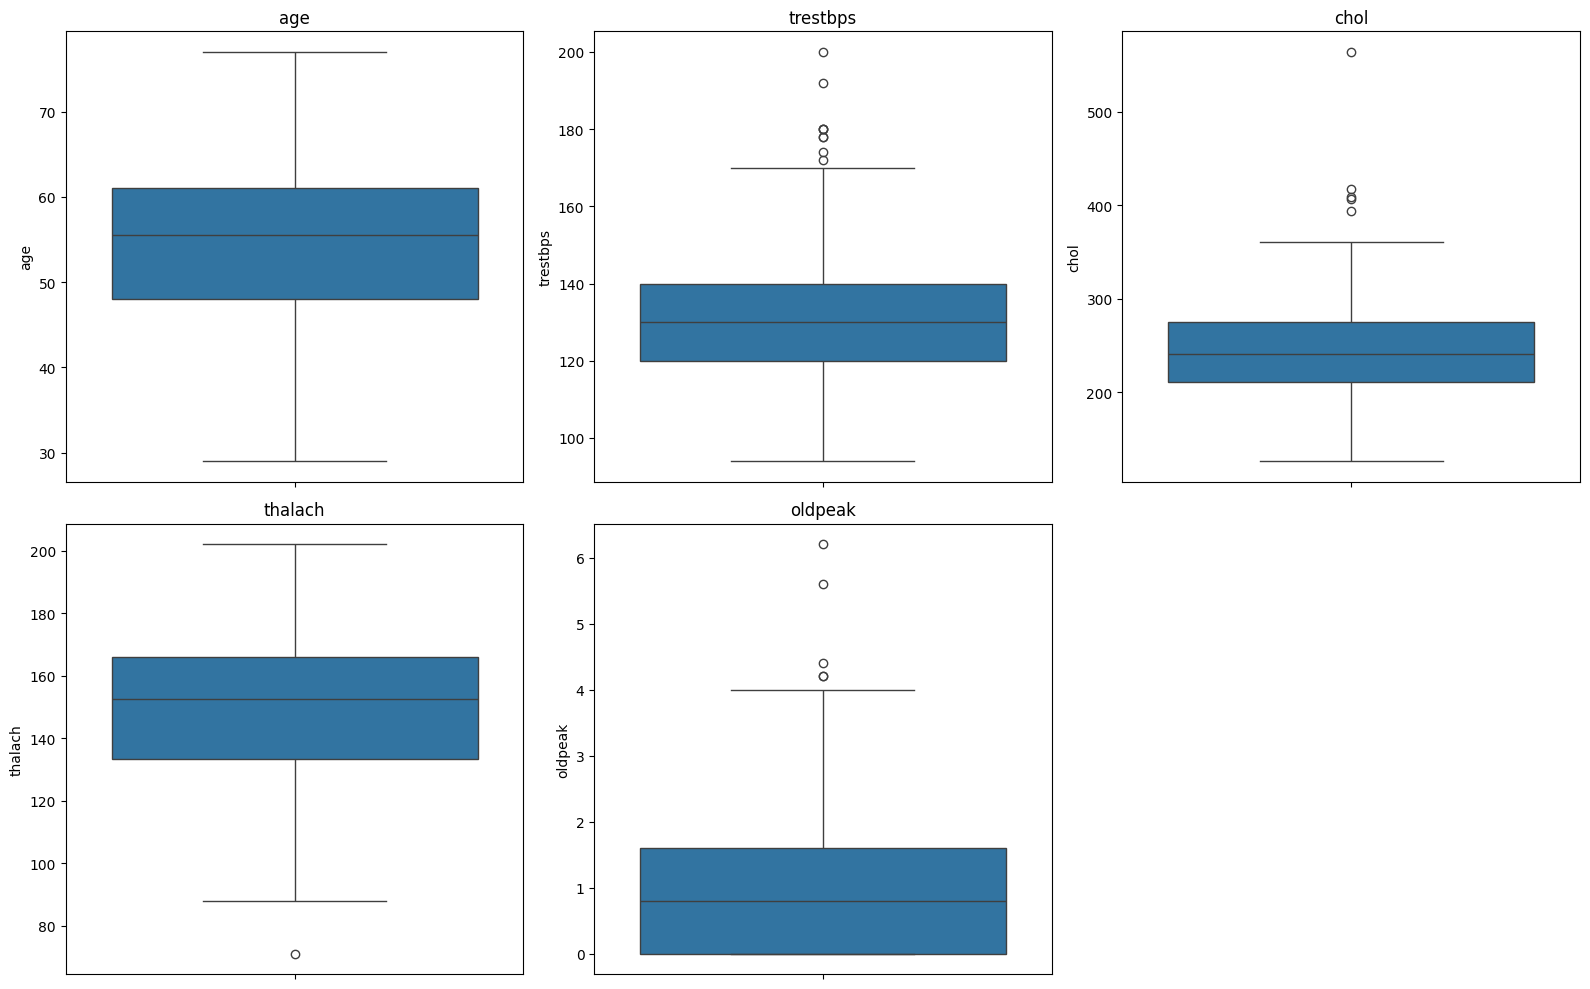

In [18]:
plt.figure(figsize = (16, 10))
i = 1
for column in num_cols:
  plt.subplot(2, 3, i)
  sns.boxplot(df_class[column])
  plt.title(column)
  i += 1
plt.tight_layout()
plt.show()

In [19]:
# Checing the outliers with IQR

# chol
Q1 = df_class['chol'].quantile(0.25)
Q3 = df_class['chol'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# viewing outliers (upper)
outliers_chol = df_class[(df_class['chol'] > upper)]
outliers_chol

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
123,65,0,2,140,417,1,0,157,0,0.8,2,1,2,1
158,67,0,2,115,564,0,0,160,0,1.6,1,0,3,1
179,56,0,0,134,409,0,0,150,1,1.9,1,2,3,0
255,62,0,0,140,394,0,0,157,0,1.2,1,0,2,1
450,63,0,0,150,407,0,0,154,0,4.0,1,3,3,0


In [20]:
# trestbps
Q1 = df_class['trestbps'].quantile(0.25)
Q3 = df_class['trestbps'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# viewing outliers (upper)
outliers_trestbps = df_class[(df_class['trestbps'] > upper)]
outliers_trestbps

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
29,55,0,0,180,327,0,2,117,1,3.4,1,0,2,0
47,66,0,0,178,228,1,1,165,1,1.0,1,2,3,0
87,59,0,0,174,249,0,1,143,1,0.0,1,0,2,0
137,64,0,0,180,325,0,1,154,1,0.0,2,0,2,1
151,54,1,1,192,283,0,0,195,0,0.0,2,1,3,0
175,56,0,0,200,288,1,0,133,1,4.0,0,2,3,0
343,52,1,2,172,199,1,1,162,0,0.5,2,0,3,1
396,68,1,2,180,274,1,0,150,1,1.6,1,0,3,0
528,59,1,3,178,270,0,0,145,0,4.2,0,0,3,1


In [21]:
# Inference:
'''
1. 'trestbps' (Resting Blood Pressure)
    Few high-value outliers. But, these values (172–200 mmHg) represent clinically plausible cases of hypertension
    Therefore, the outliers were retained.

2. 'chol' (Serum Cholesterol)
    Contains several high-value outliers as detected by the IQR method.
    The observed values (394–564 mg/dL) are medically possible
    no outlier treatment was applied

3. 'thalach' (Maximum Heart Rate Achieved)
    Few outliers were detected.
    These values fall within physiologically possible limits
    Thus, the outliers were retained

4. 'oldpeak' (ST Depression Induced by Exercise)
    Few high-value outliers due to its right-skewed distribution.
    These values indicate greater ST depression, which is clinically meaningful
    As they represent valid observations rather than anomalies, no outlier handling was performed
'''

"\n1. 'trestbps' (Resting Blood Pressure)\n    Few high-value outliers. But, these values (172–200 mmHg) represent clinically plausible cases of hypertension\n    Therefore, the outliers were retained.\n\n2. 'chol' (Serum Cholesterol)\n    Contains several high-value outliers as detected by the IQR method.\n    The observed values (394–564 mg/dL) are medically possible\n    no outlier treatment was applied\n\n3. 'thalach' (Maximum Heart Rate Achieved)\n    Few outliers were detected.\n    These values fall within physiologically possible limits\n    Thus, the outliers were retained\n\n4. 'oldpeak' (ST Depression Induced by Exercise)\n    Few high-value outliers due to its right-skewed distribution.\n    These values indicate greater ST depression, which is clinically meaningful\n    As they represent valid observations rather than anomalies, no outlier handling was performed\n"

# **Classification**

## Bivariate Analysis

### Correlation

In [22]:
# Correlation between continuous features to check for multicollinearity, and with target column
corr_mat1 = df_class[num_cols + ['target']].corr()
corr_mat1

,age,trestbps,chol,thalach,oldpeak,target
age,1.000000,0.283121,0.207216,-0.395235,0.206040,-0.221476
trestbps,0.283121,1.000000,0.125256,-0.048023,0.194600,-0.146269
chol,0.207216,0.125256,1.000000,-0.005308,0.050086,-0.081437
thalach,-0.395235,-0.048023,-0.005308,1.000000,-0.342201,0.419955
oldpeak,0.206040,0.194600,0.050086,-0.342201,1.000000,-0.429146
target,-0.221476,-0.146269,-0.081437,0.419955,-0.429146,1.000000


<Axes: >

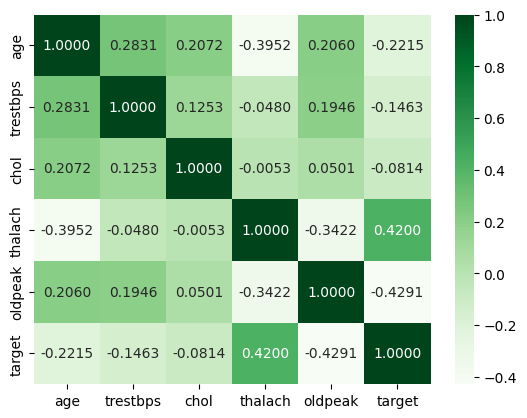

In [23]:
sns.heatmap(corr_mat1, annot=True, fmt=".4f", cmap='Greens')

In [24]:
# Inference:
  # No noticeable or extreme  multicollinearity b/w feature cols
  # Cols 'thalach' and 'oldpeak' show highest linear relation with target -> heart disease

### Mutual Information

In [25]:
# Splitting into X and y
X = df_class.drop(columns = target_col)     # target_col = 'target'
y = df_class[target_col]

# creating a mask of discrete cols in X
discrete_mask = X.columns.isin(cat_cols)

# Finding MI
mi = mutual_info_classif(X, y, discrete_features = discrete_mask, random_state = 42)

# Converting MI array to Series
mi_scores = pd.Series(mi, index=X.columns, name="Mutual Information").sort_values(ascending=False)
mi_scores

,Mutual Information
thal,0.147099
cp,0.141042
ca,0.128142
exang,0.098085
oldpeak,0.088747
thalach,0.080866
slope,0.080175
chol,0.073887
sex,0.041769
age,0.016615


In [26]:
# Inference:
  # Only 'chol' shows some useful MI with target
  # But all cols are retained as this is a medial dataset, so combinations of these cols will make stronger predictions

## Encoding

In [27]:
df_class.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [28]:
# cols to be one-hot encoded are:
ohe_cols = ['cp', 'restecg', 'thal']

# binary feature cols are already encoded -> 'sex', 'fbs' and 'exang'
# ordinal col 'slope' -> already encoded

In [29]:
# Initialize encoder
ohe_obj = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# Encode
encoded = ohe_obj.fit_transform(df_class[ohe_cols])

# Create DataFrame with encoded column names
encoded_df = pd.DataFrame(
    encoded,
    columns = ohe_obj.get_feature_names_out(ohe_cols),
    index=df_class.index
)

# Drop original columns and concatenate encoded columns
df_class = pd.concat([df_class.drop(columns = ohe_cols), encoded_df], axis=1)

# After encoding
df_class.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,thal_1,thal_2,thal_3
0,52,1,125,212,0,168,0,1.0,2,2,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,53,1,140,203,1,155,1,3.1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,70,1,145,174,0,125,1,2.6,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,61,1,148,203,0,161,0,0.0,2,1,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,62,0,138,294,1,106,0,1.9,1,3,0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [30]:
df_class.shape

(302, 19)

## Scaling

In [31]:
# cols to be scaled are:
scale_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

In [32]:
# Initialize scaler
scaler = StandardScaler()

# Scale the selected columns
df_class[scale_cols] = scaler.fit_transform(df_class[scale_cols])

# Display the first few rows, after both scaling and encoding
df_class.head(20)

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,thal_1,thal_2,thal_3
0,-0.267966,1,-0.376556,-0.667728,0,0.806035,0,-0.037124,2,2,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,-0.157260,1,0.478910,-0.841918,1,0.237495,1,1.773958,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.724733,1,0.764066,-1.403197,0,-1.074521,1,1.342748,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.728383,1,0.935159,-0.841918,0,0.499898,0,-0.899544,2,1,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.839089,0,0.364848,0.919336,1,-1.905464,0,0.739054,1,3,0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
5,0.396267,0,-1.802334,0.029032,0,-1.205722,0,-0.037124,1,0,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6,0.396267,1,-1.003898,1.383842,0,-0.418513,0,2.895104,0,3,0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
7,0.064151,1,1.619532,0.822564,0,-0.199843,1,-0.209608,1,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
8,-0.932199,1,-0.661712,0.048386,0,-0.243577,0,-0.209608,2,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
9,-0.046555,1,-0.547650,0.764500,0,-1.468126,1,1.860200,1,2,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


## TrainTestSplit

In [33]:
# Checking the class balance in target_col = 'target'
class_counts = df_class[target_col].value_counts()
ratio = class_counts.max() / class_counts.min()
print(f"Imbalance Ratio = {ratio:.2f}")

# Thus, well-balanced target col, so random splitting will be okay

Imbalance Ratio = 1.19


In [34]:
# After verifying that all cols are numeric

# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the shapes
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (241, 13)
X_test : (61, 13)
y_train: (241,)
y_test : (61,)


## **1.** Logistic Regression

In [35]:
# Initialize model using object
log_reg = LogisticRegression(random_state=42)

# Train
log_reg.fit(X_train, y_train)

# Predict
y_pred_log_reg = log_reg.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [36]:
# Evaluation Metrics:

# Accuracy
acc_log_reg = accuracy_score(y_test, y_pred_log_reg)

# Precision
pres_log_reg = precision_score(y_test, y_pred_log_reg)

# Recall
rec_log_reg = recall_score(y_test, y_pred_log_reg)

# F1-Score
f1_log_reg = f1_score(y_test, y_pred_log_reg)

## **2.** K-Nearest Neighbor

In [37]:
# Initialize model
knn = KNeighborsClassifier(n_neighbors=5)

# Train
knn.fit(X_train, y_train)

# Predict
y_pred_knn = knn.predict(X_test)

In [38]:
# Evaluation Metrics:

# Accuracy
acc_knn = accuracy_score(y_test, y_pred_knn)

# Precision
pres_knn = precision_score(y_test, y_pred_knn)

# Recall
rec_knn = recall_score(y_test, y_pred_knn)

# F1-Score
f1_knn = f1_score(y_test, y_pred_knn)

## **3.** Random Forest Classifier

In [39]:
# Initialize model
rf_class = RandomForestClassifier(n_estimators=100, random_state=42)

# Train
rf_class.fit(X_train, y_train)

# Predict
y_pred_rf_class = rf_class.predict(X_test)

In [40]:
# Evaluation Metrics:

# Accuracy
acc_rf_class = accuracy_score(y_test, y_pred_rf_class)

# Precision
pres_rf_class = precision_score(y_test, y_pred_rf_class)

# Recall
rec_rf_class = recall_score(y_test, y_pred_rf_class)

# F1-Score
f1_rf_class = f1_score(y_test, y_pred_rf_class)

## *Evaluation Metrics:*


In [41]:
print("CLASSIFICATION ALGORITHMS EVALUATION METRICS: \n")

print("Logistic Regression Performance")
print("Accuracy :", acc_log_reg)
print("Precision:", pres_log_reg)
print("Recall   :", rec_log_reg)
print("F1-Score :", f1_log_reg)

print("********************************************* \n")

print("KNN Performance \n")
print("Accuracy :", acc_knn)
print("Precision:", pres_knn)
print("Recall   :", rec_knn)
print("F1-Score :", f1_knn)

print("********************************************* \n")

print("Random Forest Performance \n")
print("Accuracy :", acc_rf_class)
print("Precision:", pres_rf_class)
print("Recall   :", rec_rf_class)
print("F1-Score :", f1_rf_class)

CLASSIFICATION ALGORITHMS EVALUATION METRICS: 

Logistic Regression Performance
Accuracy : 0.8032786885245902
Precision: 0.7297297297297297
Recall   : 0.9310344827586207
F1-Score : 0.8181818181818182
********************************************* 

KNN Performance 

Accuracy : 0.639344262295082
Precision: 0.5813953488372093
Recall   : 0.8620689655172413
F1-Score : 0.6944444444444444
********************************************* 

Random Forest Performance 

Accuracy : 0.8360655737704918
Precision: 0.7878787878787878
Recall   : 0.896551724137931
F1-Score : 0.8387096774193549


In [42]:
# Note: Recall is the key metric (When FN matter)
        # i.e., out of all the actual heart disease patients, how many the model predicted as diseased ?
        # Because FN is costly here

In [43]:
# Inferences:

# When 723 duplicate rows were removed, Random Forest showed highest Recall (86%)
  # It was able to correctly capture more diseased patients out of all actually diseased patients

# But when these duplicate cols were retained, Random Forest showed all perfect evaluation metrics (100%)
  # Because identical samples are likely to appear in both the train and testsets after random splitting.
  # Tree-based models can memorize these repeated observations, leading to data leakage and unrealistically optimistic performance.

# Random Forest was the best performing model in Classification

# **Regression**

In [44]:
# For regression

num_cols = ['age', 'trestbps', 'thalach', 'oldpeak']
cat_cols = ['sex','cp','fbs','restecg','exang','slope','ca','thal','target']

# In cat_cols :
  # nominal cols -  'cp', 'restecg', 'thal'       -> 'cp' doesn't show severity of chest pain, instead it shows type
                                                      # => Needs OHE
  # count col -  'ca'                             -> actually a discrete numerical col, treated as cat_col due to only 4 nunique
                                                      # => used as is, because it's essentially a numerical column
  # ordinal cols  - 'slope'                       -> 'slope' shows slope type like up, flat and down which has ranking
                                                      # => already encoded
  # binary cols - 'sex', 'fbs', 'exang', 'target'  => Already encoded properly

target_col =  'chol'      # shouldn't scale, nor handle any outliers
# It shows -> Serum cholesterol: Cholesterol level (in mg/dl)  => Regression

In [45]:
# Outliers were already inspected and kept as such

## Bivariate Analysis

### Correlation

In [46]:
# Correlation between continuous numerical features to check for multicollinearity, and with target column = 'chol'
corr_mat2 = df_reg[num_cols + ['chol']].corr()
corr_mat2

,age,trestbps,thalach,oldpeak,chol
age,1.000000,0.283121,-0.395235,0.206040,0.207216
trestbps,0.283121,1.000000,-0.048023,0.194600,0.125256
thalach,-0.395235,-0.048023,1.000000,-0.342201,-0.005308
oldpeak,0.206040,0.194600,-0.342201,1.000000,0.050086
chol,0.207216,0.125256,-0.005308,0.050086,1.000000


In [47]:
# Inference:
  # No noticeable or extreme  multicollinearity b/w feature cols
  # Col 'age' show highest linear relation with target -> chol

### Mutual Information

In [48]:
# Splitting into X and y
X = df_reg.drop(columns = target_col)     # target_col = 'chol'
y = df_reg[target_col]

# creating a mask of discrete cols in X
discrete_mask = X.columns.isin(cat_cols)

# Finding MI
mi = mutual_info_regression(X, y, discrete_features = discrete_mask, random_state = 42)

# Converting MI array to Series
mi_scores = pd.Series(mi, index=X.columns, name="Mutual Information").sort_values(ascending=False)
mi_scores

,Mutual Information
target,0.090790
thalach,0.058500
thal,0.052294
cp,0.048193
sex,0.040396
trestbps,0.039865
restecg,0.038659
ca,0.004072
age,0.000000
fbs,0.000000


In [49]:
# Inference:
  # most columns show weak MI with with target 'chol'
  # But all cols are retained as this is a medial dataset, so combinations of these cols will make stronger predictions

## Encoding

In [50]:
df_reg.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [51]:
# cols to be one-hot encoded are:
ohe_cols = ['cp', 'restecg', 'thal']

# binary feature cols are already encoded -> 'sex', 'fbs', 'exang' and 'target'
# ordinal col 'slope' -> already encoded

In [52]:
# Initialize encoder
ohe_obj = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# Encode
encoded = ohe_obj.fit_transform(df_reg[ohe_cols])

# Create DataFrame with encoded column names
encoded_df = pd.DataFrame(
    encoded,
    columns = ohe_obj.get_feature_names_out(ohe_cols),
    index=df_reg.index
)

# Drop original columns and concatenate encoded columns
df_reg = pd.concat([df_reg.drop(columns = ohe_cols), encoded_df], axis=1)

# After encoding
df_reg.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,thal_1,thal_2,thal_3
0,52,1,125,212,0,168,0,1.0,2,2,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,53,1,140,203,1,155,1,3.1,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,70,1,145,174,0,125,1,2.6,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,61,1,148,203,0,161,0,0.0,2,1,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,62,0,138,294,1,106,0,1.9,1,3,0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


## Scaling

In [53]:
# cols to be scaled are:
scale_cols = ['age', 'trestbps', 'thalach', 'oldpeak']

In [54]:
# Initialize scaler
scaler = StandardScaler()

# Scale the selected columns
df_reg[scale_cols] = scaler.fit_transform(df_reg[scale_cols])

# Display the first few rows, after both scaling and encoding
df_reg.head(20)

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,thal_1,thal_2,thal_3
0,-0.267966,1,-0.376556,212,0,0.806035,0,-0.037124,2,2,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,-0.157260,1,0.478910,203,1,0.237495,1,1.773958,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.724733,1,0.764066,174,0,-1.074521,1,1.342748,0,0,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.728383,1,0.935159,203,0,0.499898,0,-0.899544,2,1,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.839089,0,0.364848,294,1,-1.905464,0,0.739054,1,3,0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
5,0.396267,0,-1.802334,248,0,-1.205722,0,-0.037124,1,0,1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6,0.396267,1,-1.003898,318,0,-0.418513,0,2.895104,0,3,0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
7,0.064151,1,1.619532,289,0,-0.199843,1,-0.209608,1,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
8,-0.932199,1,-0.661712,249,0,-0.243577,0,-0.209608,2,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
9,-0.046555,1,-0.547650,286,0,-1.468126,1,1.860200,1,2,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


## TrainTestSplit

In [55]:
# After verifying that all cols are numeric

# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the shapes
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (241, 13)
X_test : (61, 13)
y_train: (241,)
y_test : (61,)


## **1.** Linear Regression

In [56]:
# Create model object
lin_reg = LinearRegression()

# train the model
lin_reg.fit(X_train, y_train)

# make prediction using the model
y_pred_lin_reg = lin_reg.predict(X_test)

In [57]:
# Evaluation Metrics:

# Mean Absolute Error (MAE)
mae_lin_reg = mean_absolute_error(y_test, y_pred_lin_reg)

# Mean Squared Error (MSE)
mse_lin_reg = mean_squared_error(y_test, y_pred_lin_reg)

# R-2 Score
r2_lin_reg = r2_score(y_test, y_pred_lin_reg)

## **2.** Support Vector Machines Regression

In [58]:
# object
svr_model = SVR()   # default kernel = 'rbf'

# Train the model
svr_model.fit(X_train, y_train)

# make predictions on X_test
y_pred_svr = svr_model.predict(X_test)

In [59]:
# Evaluation Metrics:

# Mean Absolute Error (MAE)
mae_svr = mean_absolute_error(y_test, y_pred_svr)

# Mean Squared Error (MSE)
mse_svr = mean_squared_error(y_test, y_pred_svr)

# R-2 Score
r2_svr = r2_score(y_test, y_pred_svr)

## **3.** Random Forest Regressor

In [60]:
# object
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)

# Train
rf_reg.fit(X_train, y_train)

# Predict
y_pred_rf_reg = rf_reg.predict(X_test)

In [61]:
# Evaluation Metrics:

# Mean Absolute Error (MAE)
mae_rf_reg = mean_absolute_error(y_test, y_pred_rf_reg)

# Mean Squared Error (MSE)
mse_rf_reg = mean_squared_error(y_test, y_pred_rf_reg)

# R-2 Score
r2_rf_reg = r2_score(y_test, y_pred_rf_reg)

## *Evaluation Metrics:*

In [65]:
print("REGRESSION ALGORITHMS EVALUATION METRICS: \n")

print("Linear Regression Performance")
print("MAE       :", mae_lin_reg)
print("MSE       :", mse_lin_reg)
print("R-2 Score :", r2_lin_reg)

print("***************************************** \n")

print("Support Vector Regression Performance")
print("MAE       :", mae_svr)
print("MSE       :", mse_svr)
print("R-2 Score :", r2_svr)

print("***************************************** \n")

print("Random Forest Regressor Performance")
print("MAE       :", mae_rf_reg)
print("MSE       :", mse_rf_reg)
print("R-2 Score :", r2_rf_reg)

REGRESSION ALGORITHMS EVALUATION METRICS: 

Linear Regression Performance
MAE       : 34.1343246674712
MSE       : 2060.7171144067893
R-2 Score : -0.12339570807080635
***************************************** 

Support Vector Regression Performance
MAE       : 32.489070957036525
MSE       : 1837.6798177710252
R-2 Score : -0.001807383293652487
***************************************** 

Random Forest Regressor Performance
MAE       : 35.245737704918035
MSE       : 2119.5466901639343
R-2 Score : -0.15546653062629745


In [63]:
# Note: R-2 Score is the key metric


In [64]:
# Inferences:
